# 🏀 K.A.W.H.I. - Defense Optimization With Gradient Flows
---
## Feature Engineering & Validation

This notebook validates the tactical and physical metrics used for defensive optimization, specifically Expected Field Goal percentage ($xFG\%$) and Instantaneous Shot Threat ($IST$).

**Author:** Caden Pascual
**Environment:** `kawhi_env`  
**Dataset:** 100-play NBA Audit

## Import Functions
---

In [2]:
import pandas as pd
import numpy as np
import optuna.visualization as vis
import sys
from pathlib import Path

# Add project root to path for imports
ROOT = Path.cwd().parent  
sys.path.append(str(ROOT))
from src.data_io.maps import load_maps_npz
from src.viz.court import plot_players_by_name
from src.gradient_flows.animation import extract_plot_trajectories, animate_standard_play
from src.gradient_flows.audit import create_trial_browser, audit_final_results, generate_optimization_viz
from src.gradient_flows.animation import animate_side_by_side_courts, animate_triple_comparison
from src.gradient_flows.poster import plot_ist_optimization_map, plot_triple_ist_shift

## 📍 Step 1: Spatial Quality Maps
Select specific players to visualize their offensive quality maps using Expected Points Per Shot ($xPPS$) maps.

---

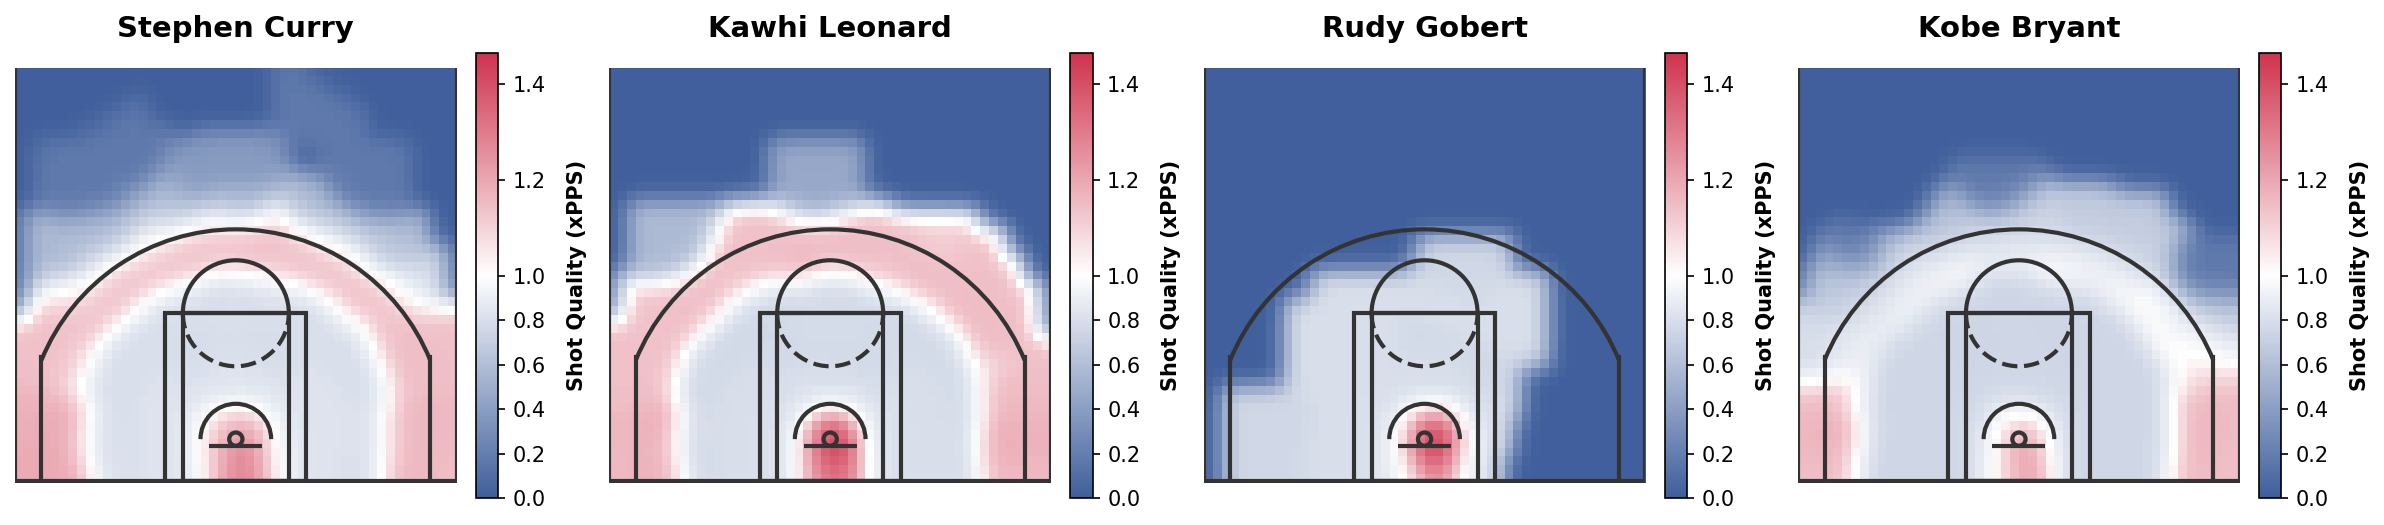

In [3]:
# Load Player Quality Maps
maps, meta = load_maps_npz("../data/demo/processed/maps_1ft_xpps.npz")

players = ['Stephen Curry', 'Kawhi Leonard', 'Rudy Gobert', 'Kobe Bryant']
plot_players_by_name(players, maps, meta)

## 🎥 Step 2: Baseline Trajectory Verification
Visualize the original NBA defensive movement to ensure coordinate accuracy and establish a performance baseline before applying the optimization logic. 

---

In [3]:
# Choose a posession to animate between 0-103
posession = 5
traj_df = pd.read_parquet("../data/demo/processed/demo_traj.parquet")
sample_play = traj_df.iloc[posession]
off_traj, def_traj, ball_traj = extract_plot_trajectories(sample_play)
animate_standard_play(off_traj, def_traj, ball_traj)

## Step 3: Choose Best Optuna Trial
Run the Code below and play with the figure to choose your favorite trial.

In [4]:
traj_df = pd.read_parquet("../data/demo/processed/demo_traj.parquet")
DB_PATH = "sqlite:///../data/demo/processed/demo-ist-tuning.db"
STUDY_NAME = "demo-ist-tuning"
generate_optimization_viz(DB_PATH, STUDY_NAME)

In [5]:
# View how Trials work visually
create_trial_browser(traj_df, DB_PATH, STUDY_NAME, animate_side_by_side_courts)

## Step 4: Verify Our Models Effectiveness
Check out your final Model

In [6]:
# Load Final simulated dataset
final_df = pd.read_parquet("../data/demo/final/demo_simulated_traj.parquet")
audit_final_results(
    df=final_df,
    triple_animate_fn=animate_triple_comparison
)

In [7]:
# Run the final Triple-Shift Dashboard
plot_triple_ist_shift(final_df)

In [8]:
plot_ist_optimization_map(final_df)